### Importing Liabraries

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Inspecting Data

In [144]:
df = pd.read_csv("global_retail_sales_dataset.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 5,000 rows x 16 columns


,Order_ID,Order_Date,Customer_Name,City,Country,Sales_Channel,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Revenue,Cost,Profit,Payment_Method,Customer_Rating
0,ORD-100001,2024-01-24,Benjamin Mcclure,Chicago,USA,Mobile App,Electronics,Tablet,7,681.05,0.21,3766.21,3158.69,607.52,Cash on Delivery,3
1,ORD-100002,2023-01-02,Sherry Barnes,Berlin,Germany,Retail Store,Home & Living,Sofa,3,856.30,0.08,2363.39,1491.07,872.32,Credit Card,5
2,ORD-100003,2024-11-14,Kenneth Mccoy,New York,USA,Online,Beauty,Perfume,6,1835.46,0.03,10682.38,6030.02,4652.36,Debit Card,1
3,ORD-100004,2023-12-18,Carol Dudley,Istanbul,Turkey,Mobile App,Home & Living,Curtains,8,678.00,0.21,4284.96,3443.83,841.13,Bank Transfer,2
4,ORD-100005,2024-03-20,Ann Skinner,Istanbul,Turkey,Mobile App,Sports,Tennis Racket,6,51.12,0.22,239.24,182.60,56.64,Cash on Delivery,5


In [145]:
print("-- Column Type --")
print(df.dtypes)
print("\n -- Missing Values --")
print(df.isnull().sum())
print("\n -- Duplicated Rows --")
print(df.duplicated().sum())

-- Column Type --
Order_ID             object
Order_Date           object
Customer_Name        object
City                 object
Country              object
Sales_Channel        object
Product_Category     object
Product_Name         object
Quantity              int64
Unit_Price          float64
Discount_Percent    float64
Revenue             float64
Cost                float64
Profit              float64
Payment_Method       object
Customer_Rating       int64
dtype: object

 -- Missing Values --
Order_ID            0
Order_Date          0
Customer_Name       0
City                0
Country             0
Sales_Channel       0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Revenue             0
Cost                0
Profit              0
Payment_Method      0
Customer_Rating     0
dtype: int64

 -- Duplicated Rows --
0


In [146]:
# Fixing Order_Date data type.
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Date'].dtype

dtype('<M8[ns]')

### Feature Engineering

In [147]:
# Creating Columns
df['Profit_Margin %'] = ((df['Profit']/df['Revenue']) * 100).round(3)

df['Discount_Tier'] = pd.cut(df['Discount_Percent'],
                             bins = [0, 0.10, 0.20, 1.0],
                             labels = ['Low', 'Medium', 'High'])

import datetime as dt
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month_name()

print("\n -- New Features --")
print(df[['Profit_Margin %', 'Discount_Tier', 'Year', 'Month']].head(10))


 -- New Features --
   Profit_Margin % Discount_Tier  Year     Month
0           16.131          High  2024   January
1           36.910           Low  2023   January
2           43.552           Low  2024  November
3           19.630          High  2023  December
4           23.675          High  2024     March
5           23.700          High  2025   January
6           32.207        Medium  2025     March
7           31.611          High  2024       May
8           27.299           Low  2024   January
9           36.026           Low  2024     March


### Exploratory Data Analysis (EDA)


#### 1.1 Which category has highest revenue and profit?

In [148]:
df.groupby('Product_Category')[['Revenue','Profit']].sum().sort_values('Revenue', ascending=False).reset_index().round(2)

,Product_Category,Revenue,Profit
0,Home & Living,5351720.47,1521121.36
1,Electronics,4984890.43,1453166.66
2,Beauty,4957630.94,1391374.53
3,Fashion,4890667.21,1415769.56
4,Sports,4797073.32,1363267.36


#### Observation:
- Home & Living leads in both revenue (5.35M) and profit (1.52M), making it the strongest category overall.
- Sports ranks last in both revenue (4.79M) and profit (1.36M), making it the weakest performing category.
- The gap between the highest (Home & Living) and lowest (Sports) category is around 554K in revenue and 157K in profit - not a massive difference, meaning all categories are fairly competitive.

#### 1.2 Which country contributes most?

In [149]:
df.groupby('Country')['Revenue'].sum().sort_values(ascending = False).reset_index().round(2)  

,Country,Revenue
0,USA,3964301.07
1,India,3828635.98
2,Pakistan,3776641.39
3,UK,2433211.17
4,Germany,1275580.48
5,Turkey,1269259.56
6,UAE,1260817.39
7,Canada,1248359.77
8,South Africa,1247436.42
9,France,1222422.17


#### Observation:
- USA is the top revenue-generating country with 3.96M, followed closely by India (3.82M) and Pakistan (3.77M).
- These three countries together account for a significantly larger share compared to the rest of the markets.
- UK stands out as the only mid-tier country with noticeably higher revenue (2.43M) compared to all others below it.
- Germany, Turkey, UAE, Canada, South Africa, France, Singapore, Japan, and Australia are all tightly clustered between 1.11M and 1.27M - meaning the company has an even but low-penetration presence across these markets.

#### 1.3 Which sales channel performs best?

In [150]:
df.groupby('Sales_Channel')[['Revenue', 'Profit']].sum().sort_values('Revenue', ascending = False).reset_index().round(2)

,Sales_Channel,Revenue,Profit
0,Online,8502474.37,2414758.08
1,Retail Store,8434342.48,2436574.99
2,Mobile App,8045165.52,2293366.40


#### Observation:
- Online leads in total revenue (8.50M) but ranks second in profit (2.41M).
- Retail Store ranks second in revenue (8.43M) but generates the highest total profit (2.43M), making it the most profitable channel overall.
- Mobile App has the lowest revenue (8.04M) and profit (2.29M) across all three channels.
- The difference between channels is small, but Retail Store's ability to generate more profit on slightly less revenue than Online suggests better cost efficiency in physical stores.

#### 1.4 Profit Margin % by Category


In [151]:
df.groupby('Product_Category')['Profit_Margin %'].mean().sort_values(ascending=False).reset_index().round(3)

,Product_Category,Profit_Margin %
0,Electronics,28.912
1,Fashion,28.701
2,Sports,28.620
3,Home & Living,28.544
4,Beauty,28.302


#### Observation:
- Electronics has the highest profit margin at 28.91%, making it the most margin-efficient category despite not being the revenue leader.
- Beauty has the lowest margin at 28.30%, sitting at the bottom across all five categories.
- The overall margin range across all categories is only 0.6 percentage points - meaning no category has a serious margin problem or a standout advantage.
- All categories are performing at a similar efficiency level, so margin alone cannot be used to prioritize one category over another.

#### 1.5.1 Revenue & Profit by Month

In [158]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df.groupby('Month')[['Revenue', 'Profit']].sum().reindex(month_order).round(2)

,Revenue,Profit
Month,,
January,2757671.68,785219.22
February,2457590.15,685910.67
March,2706605.10,781502.25
April,2730468.18,791457.66
May,2508746.13,731744.65
June,2127560.13,605748.69
July,1594255.75,448249.60
August,1679339.25,480237.93
September,1595059.72,457191.07


#### 1.5.2 Chart

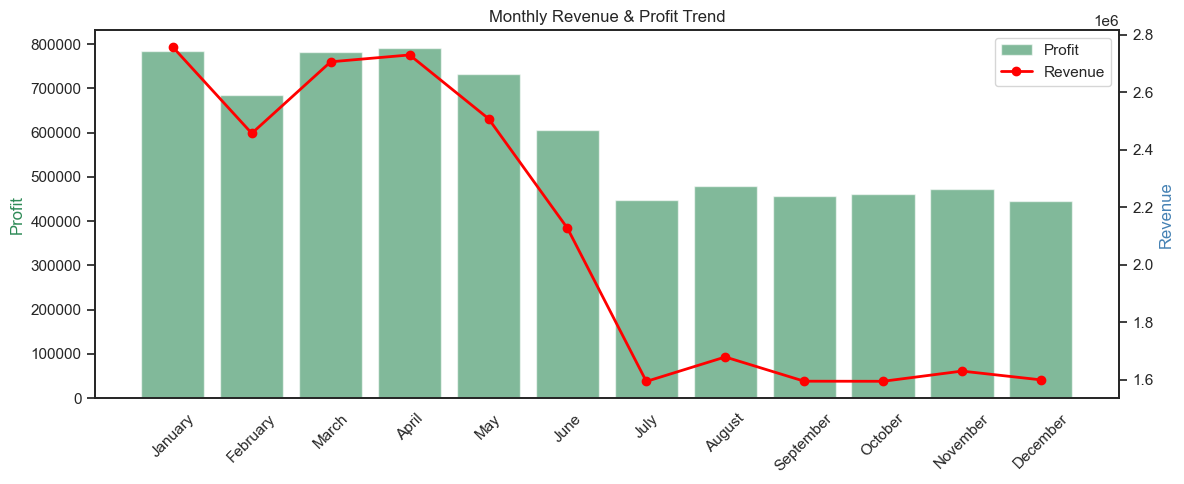

In [156]:
# Global style
sns.set_theme(style='white')

# -- MONTH --
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

monthly_revenue = df.groupby('Month')['Revenue'].sum().reindex(month_order)
monthly_profit = df.groupby('Month')['Profit'].sum().reindex(month_order)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar - Profit
ax1.bar(monthly_profit.index, monthly_profit.values, color='seagreen', alpha=0.6, label='Profit')
ax1.set_ylabel('Profit', color='seagreen')
ax1.tick_params(axis='x', rotation=45)

# Line - Revenue
ax2 = ax1.twinx()
ax2.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='red', linewidth=2, label='Revenue')
ax2.set_ylabel('Revenue', color='steelblue')

plt.title('Monthly Revenue & Profit Trend')
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
plt.tight_layout()
plt.show()

#### Observation:
- January is the strongest month with the highest revenue (2.75M) and profit (785K), suggesting a strong post-holiday or new year demand spike.
- April is the second strongest month in profit (791K) despite slightly lower revenue than January, indicating better cost efficiency in April.
- June marks the beginning of a sharp decline - revenue drops to 2.12M and profit to 605K, the lowest in the first half of the year.
- July through December form a consistently weak second half, with revenue staying between 1.59M and 1.67M every month.
- The business is heavily front-loaded - the first six months significantly outperform the last six, which is a seasonal pattern the company needs to address.
- Despite the sharp revenue drop in the second half, profit margins improve - suggesting the business operates more cost-efficiently during low-demand months, possibly due to reduced operational and marketing spend.

#### 1.6 Summary Stats

In [108]:
print("=== BASIC SUMMARY ===")
print(f"Total Orders     : {len(df)}")
print(f"Total Revenue    : {df['Revenue'].sum():,.2f}")
print(f"Total Profit     : {df['Profit'].sum():,.2f}")
print(f"Avg Profit Margin: {df['Profit_Margin %'].mean():.2f}%")
print(f"Avg Order Value  : {df['Revenue'].mean():,.2f}")
print(f"Avg Rating       : {df['Customer_Rating'].mean():.2f}")

=== BASIC SUMMARY ===
Total Orders     : 5000
Total Revenue    : 24,981,982.37
Total Profit     : 7,144,699.47
Avg Profit Margin: 28.62%
Avg Order Value  : 4,996.40
Avg Rating       : 3.02


###  Discount Impact Analysis

#### 2.1 Average Revenue & Profit by Discount Tier

In [110]:
df.groupby('Discount_Tier')[['Revenue','Profit','Profit_Margin %']].mean().reset_index().round(2)

,Discount_Tier,Revenue,Profit,Profit_Margin %
0,Low,5336.26,1519.24,28.48
1,Medium,4838.32,1393.91,28.82
2,High,4453.29,1282.64,28.61


#### Observation:
##### Both revenue and profit go down as discounts increase.
- High discount orders generate ~16.5% less revenue and ~15.6% less profit compared to low discount orders.
- Higher discounts are not attracting bigger purchases, they are simply reducing what the company earns per order.

#### 2.2 Average Profit Margin by Discount Tier and Product Category

In [115]:
df.groupby(['Product_Category','Discount_Tier'])['Profit_Margin %'].mean().round(3).unstack()

Discount_Tier,Low,Medium,High
Product_Category,,,
Beauty,28.656,28.233,27.957
Electronics,28.110,29.361,29.633
Fashion,28.885,28.948,28.140
Home & Living,28.249,29.103,28.059
Sports,28.553,28.410,29.245


#### Observation:
##### Discounts have no strategic logic.
Discount tiers show negligible variation in profit margin across all product categories (range: 27.9% – 29.6%), suggesting discounts are uniformly applied and not differentiated by category or customer behaviour.

#### 2.3 Correlation: Discount % vs Profit Margin % (Chart)

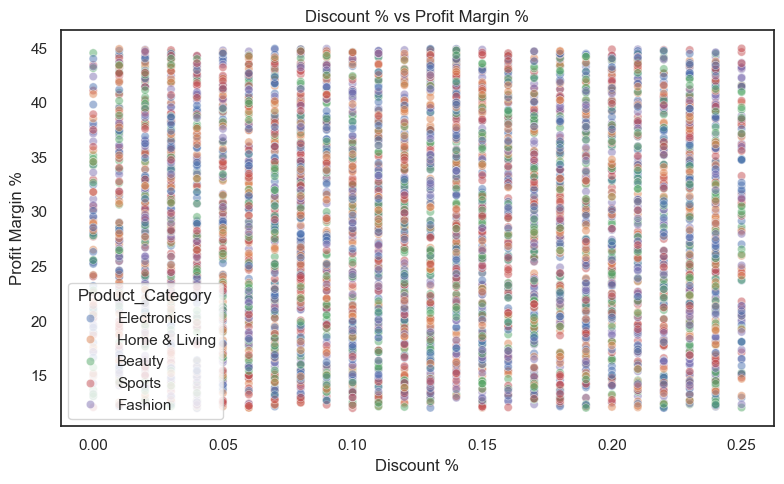

In [117]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount_Percent', y='Profit_Margin %', 
                hue='Product_Category', alpha=0.5)
plt.title('Discount % vs Profit Margin %')
plt.xlabel('Discount %')
plt.ylabel('Profit Margin %')
plt.tight_layout()
plt.show()

#### Observation:
- The scatter plot shows no clear pattern between discount percentage and profit margin.
- Dots are randomly spread across all discount levels from 0% to 25%, confirming that increasing or decreasing the discount has no consistent effect on profit margin.
- This suggests discounts in this dataset are applied randomly, not strategically.

### Country, Category & Channel Dynamics
#### 3.1 Which Country is Most Profitable?

In [119]:
df.groupby('Country')[['Revenue','Profit','Profit_Margin %']].mean().sort_values('Profit_Margin %', ascending=False).round(2)

,Revenue,Profit,Profit_Margin %
Country,,,
Germany,5021.97,1472.19,29.75
Australia,4622.66,1347.90,29.53
Japan,5260.64,1534.45,28.96
UK,4599.64,1331.00,28.92
Canada,5095.35,1486.82,28.80
Singapore,5553.04,1537.62,28.68
USA,5141.77,1475.71,28.57
India,5244.71,1492.70,28.55
South Africa,4816.36,1400.03,28.45


#### Observation:
- Germany leads with the highest profit margin at 29.75%, followed by Australia (29.53%) and Japan (28.96%).
- Pakistan, Turkey, and France sit at the bottom with margins around 28.13 - 28.14%.
- Overall spread across all 13 countries is very narrow - just 1.6 percentage points - meaning no country is significantly outperforming or underperforming others in terms of margin efficiency.

#### 3.2 Which Sales Channel has the Best Profit per Order?

In [120]:
df.groupby('Sales_Channel')[['Revenue','Profit','Profit_Margin %']].mean().round(2)

,Revenue,Profit,Profit_Margin %
Sales_Channel,,,
Mobile App,4953.92,1412.17,28.59
Online,4957.71,1408.02,28.43
Retail Store,5077.87,1466.93,28.84


#### Observation:
- Retail Store generates the highest average revenue (5077.87) and profit (1466.93) per order with a margin of 28.84%, making it the most profitable channel per transaction.
- Mobile App and Online are very close to each other in all three metrics.
- Despite being the traditional channel, Retail Store is quietly outperforming digital channels on a per-order basis.

#### 3.3 Where is the Most Profit Coming From?

In [124]:
df.groupby(['Country','Product_Category'])['Profit'].sum().unstack().round(2)

Product_Category,Beauty,Electronics,Fashion,Home & Living,Sports
Country,,,,,
Australia,53702.03,67763.78,52281.29,55699.42,96745.73
Canada,92429.48,79263.08,58217.09,63042.07,71318.26
France,64324.02,87616.70,76802.20,70659.64,43634.90
Germany,80010.04,60121.89,53791.30,89922.46,90089.31
India,201389.19,242697.19,248976.22,217656.85,178950.19
Japan,31875.12,71817.23,84407.67,73203.08,65534.38
Pakistan,208297.66,180477.48,218834.30,221675.71,226997.17
Singapore,81512.24,60869.61,49236.08,89751.87,55367.97
South Africa,78504.28,72264.29,58884.78,93396.01,59558.23


#### Observation:
- USA and India are the two biggest profit contributors overall across all categories.
- USA dominates in Home & Living (245K) and Fashion (245K), while India leads in Fashion (248K) and Electronics (242K).
- Pakistan surprisingly ranks third in total profit volume, driven strongly by Sports (226K) and Home & Living (221K).
- Japan and Australia are the weakest contributors, likely due to lower order volumes rather than poor margins.

#### 3.4 Which Category & Channel Combination Performs Best?

In [125]:
df.groupby(['Sales_Channel','Product_Category'])['Profit'].sum().unstack().round(2)

Product_Category,Beauty,Electronics,Fashion,Home & Living,Sports
Sales_Channel,,,,,
Mobile App,471891.05,468872.94,452765.63,427968.35,471868.43
Online,433007.81,516124.72,471018.88,511565.32,483041.35
Retail Store,486475.67,468169.00,491985.05,581587.69,408357.58


#### Observation:
- Retail Store + Home & Living is the single highest performing combination with 581K in profit, making it the standout pair.
- Online + Electronics (516K) and Online + Home & Living (511K) also perform strongly.
- Mobile App generates the most balanced profits across all categories with no single category dominating.
- The weakest combination is Retail Store + Sports (408K), suggesting sports products sell better online or through the app.

#### 3.5 Top 5 and Bottom 5 Countries by Profit Margin (Chart)

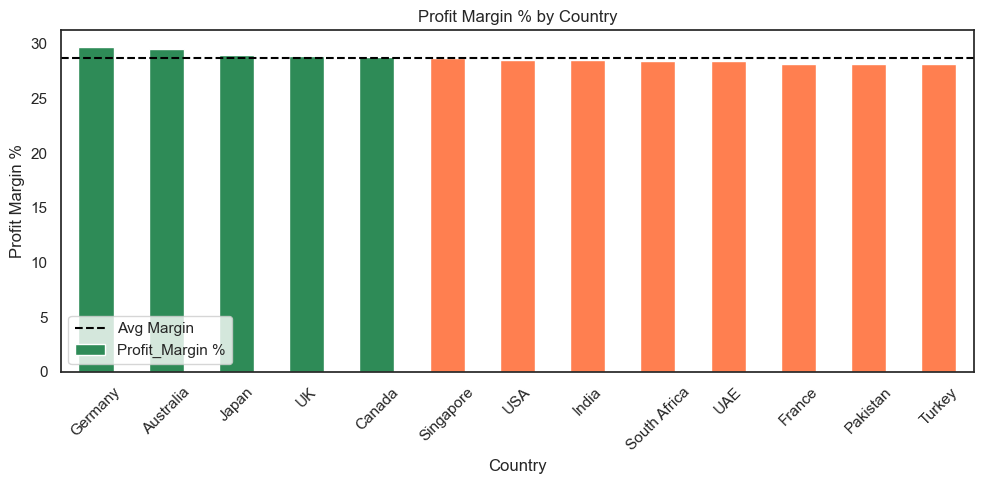

In [123]:
country_margin = df.groupby('Country')['Profit_Margin %'].mean().sort_values(ascending=False).round(2)

plt.figure(figsize=(10, 5))
country_margin.plot(kind='bar', color=['seagreen' if x >= country_margin.mean() else 'coral' for x in country_margin])
plt.title('Profit Margin % by Country')
plt.xlabel('Country')
plt.ylabel('Profit Margin %')
plt.axhline(y=country_margin.mean(), color='black', linestyle='--', label='Avg Margin')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observation:
- Only 5 countries - Germany, Australia, Japan, UK, and Canada - are above the average margin line, shown in green.
- The remaining 8 countries fall below average, shown in orange.
- The difference between the highest (Germany 29.75%) and lowest (Turkey/Pakistan 28.13%) is barely 1.6%.
- No country is in a critical underperformance zone —-  the business maintains consistent margins globally.

#### 3.6.1 Retail Store vs Online vs Mobile App by Country

In [126]:
df.groupby(['Country','Sales_Channel'])['Profit'].sum().unstack().round(2)

Sales_Channel,Mobile App,Online,Retail Store
Country,,,
Australia,84466.24,117530.85,124195.16
Canada,108823.98,142103.39,113342.61
France,114928.37,125575.32,102533.77
Germany,106586.74,125017.48,142330.78
India,375125.34,339571.23,374973.07
Japan,87288.54,140519.67,99029.27
Pakistan,323734.36,410543.25,322004.71
Singapore,101636.70,100883.58,134217.49
South Africa,111534.93,102835.49,148237.17


#### 3.6.2 Chart

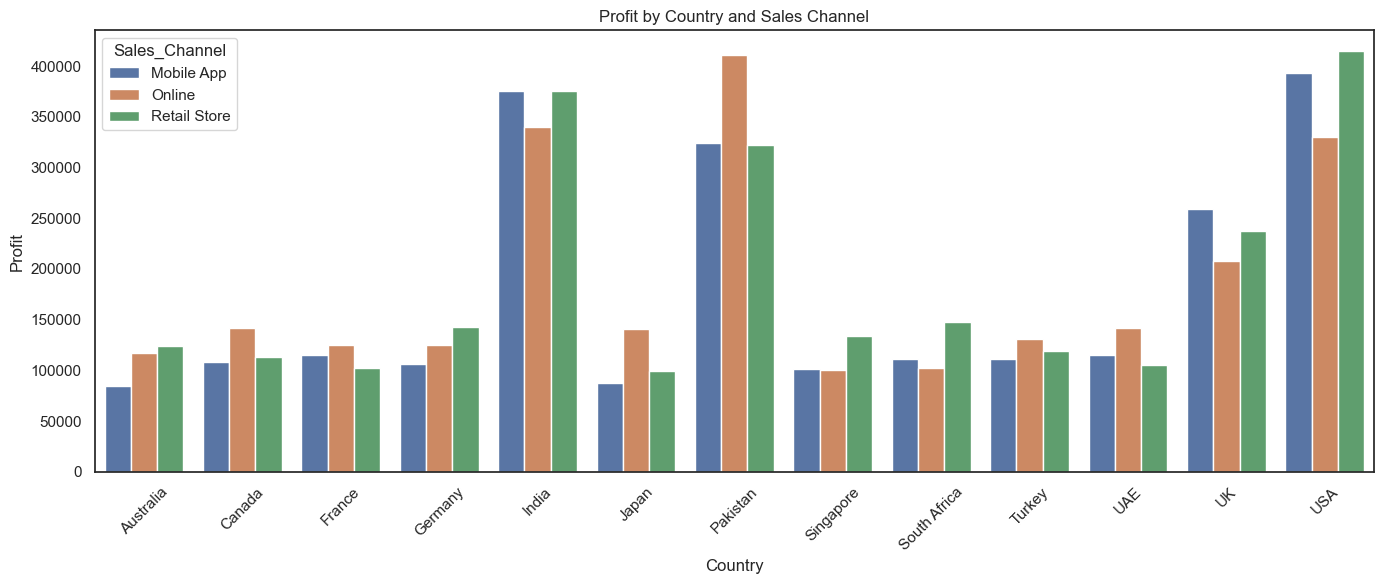

In [127]:
channel_country = df.groupby(['Country','Sales_Channel'])['Profit'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=channel_country, x='Country', y='Profit', hue='Sales_Channel')
plt.title('Profit by Country and Sales Channel')
plt.xlabel('Country')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observation:
- USA and India are the top profit contributors across all three channels with no significant weak spot.
- Pakistan and Japan strongly prefer Online, while Germany and Australia lean towards Retail Store.
- India is the only country where Mobile App and Retail Store are almost equal, showing strong multi-channel adoption.
- No single channel dominates globally - channel preference clearly varies by country, meaning the company needs a region-specific channel strategy rather than a uniform approach.

### Business Recommendations
1. Focus sales investment on USA, India and Pakistan
2. Strengthen the Retail Store & Home and Living combination
3. Build a strategic discounting framework
4. Address the second-half revenue decline
5. Adopt a region-specific channel strategy
6. Invest in Mobile App growth

### Conclusion
This analysis looked at 5,000 global retail orders to identify what is driving profitability and where the
business has room to improve. The findings show that while margins are healthy and consistent across
countries and categories, there are clear gaps in how discounts are applied, how channels are utilized
by region and how the business manages its seasonal performance dip in the second half of the year.